# Figure 5 — plotting

**This notebook does no analysis.** It loads the tables in `analysis/figure5/` and renders one
panel per file. The numbers come from

```
python analysis/scripts/figure5_data.py               # all panels (~20 min, full resolution)
python analysis/scripts/figure5_data.py --panels C    # just panel C
python analysis/scripts/figure5_data.py --stride 20   # fast smoke test
```

Re-run that script when new simulation data lands; re-run *this* notebook to change how a panel
looks. Each panel is written to its own PDF + PNG in `figures/`, for assembly in Inkscape
alongside the VMD structures.

**Every cell below is self-contained.** It carries its own imports, its own style, and its own
display settings — limits, colours, colour ceilings, output name — so you can restart the kernel,
run one cell, and get one figure. Nothing is inherited from a settings cell above; the only shared
code is `analysis/scripts/figure5_plot.py`, which holds mechanics (loading, the reliability
truncation, the file-naming rule) and no styling.

| Panel | File | Shows |
|---|---|---|
| A | `A_fes2d_qcore_nidr.dat` | apo $F(Q_\mathrm{core}, n_\mathrm{IDR-core})$ — unstructuring |
| B | `B_helicity_perhelix_vs_qcore.dat` | $\langle S_\alpha\rangle$ per helix vs $Q_\mathrm{core}$ — H2 melts most |
| C | `C_pmf2d_qcore_total.dat` + `C_medoids_cvs.dat` | apo $F(Q_\mathrm{core}, S_\alpha^{\mathrm{tot}})$ + the two state medoids |
| D1 | `D_pmf_bend_{DNA,holo}.dat` | $F(\mathrm{bend})$ — free DNA vs bound |
| D2 | `D_pmf_de2e_{DNA,holo}.dat` | $F(d_\mathrm{e-e})$ — free DNA vs bound |
| E | `E_pmf2d_idrdna_bend.dat` | $F(n_\mathrm{IDR-DNA}, \mathrm{bend})$ — bending needs IDR contacts |
| F1 | `F1_equil_2Nhp6A_h3.dat` | 2Nhp6A H3 distortion (unbiased MD) |
| F2 | `F2_equil_bend_hist.dat` | bend angle, unbiased MD |

**Conventions applied at plot time** (the `.dat` files stay full-range, by design): a sampling mask
(`MIN_VISITS`), the reliability truncation (std ≤ `STD_CEIL`, contiguous from the minimum), and a
per-bin ESS floor for reweighted means. Every curve carries a mean ± std band. The N-terminal tail
is labelled **IDR**.

## Provenance of the data being plotted

Optional — run it to see which dataset, how long, and which reweighting gates each panel rests on.

In [1]:
import sys
sys.path.insert(0, "analysis/scripts")
import figure5_plot as f5

META = f5.load_meta()
print(f"data generated {META['generated']} on {META['host']} "
      f"| stride {META['stride']} | {META['n_snaps']} snapshots")
print(f"DNA-only source: {META['dna_source']}")
print("panels last recomputed:", ", ".join(f"{k} {v}" for k, v in
                                           sorted(META.get("panels_last_run", {}).items())))
if "reweighting_apo" in META:
    r = META["reweighting_apo"]
    print(f"\napo c(t) reweighting: ESS = {r['ess']:,.0f} ({r['ess_percent']}%)  "
          f"gate MAD bulk = {r['gate_mad_qcore_bulk']} kJ/mol  -> "
          f"{'PASS' if r['gate_pass'] else 'FAIL'}")
for k, v in META.get("D", {}).items():
    print(f"{v['label']:12s} {v['ns_per_walker']:.0f} ns/walker  ESS {v['ess_percent']}%  "
          f"MAD(de2e) {v['gate_mad_de2e']} kJ/mol  -> {'OK' if v['gate_pass'] else 'CHECK'}")
print()
for f in META["flags"]:
    print("FLAG:", f)

data generated 2026-07-31 13:10 | stride 1 | 5 snapshots
DNA-only source: data/DNA_wall2
panels last recomputed: A 2026-07-30 18:23, B 2026-07-30 18:23, C 2026-07-30 18:23, D 2026-07-31 12:13, E 2026-07-31 12:13, F 2026-07-31 13:10

apo c(t) reweighting: ESS = 1,014,824 (3.4%)  gate MAD bulk = 2.48 kJ/mol  -> PASS
DNA alone    100 ns/walker  ESS 52.0%  MAD(de2e) 0.75 kJ/mol  -> OK
Nhp6A:DNA    300 ns/walker  ESS 30.2%  MAD(de2e) 1.59 kJ/mol  -> OK

FLAG: 2Nhp6A MetaD excluded by design (reweighting gate fails: ESS~0%, MAD=4.7 kJ/mol); panel F uses unbiased equilibrium MD only.


## Panel A — apo $F(Q_\mathrm{core},\, n_\mathrm{IDR-core})$

*"In the apo form, the native state ensemble predominantly involves fluctuations in the number of
IDR–folded core contacts … unstructuring (decrease in Q) is possible."*

Both CVs are biased, so this is `sum_hills`, no reweighting involved.

  saved figures/1Nhp6A_apo_large_fes2d_qcore_nidr_fig5a_v3.[pdf|png]


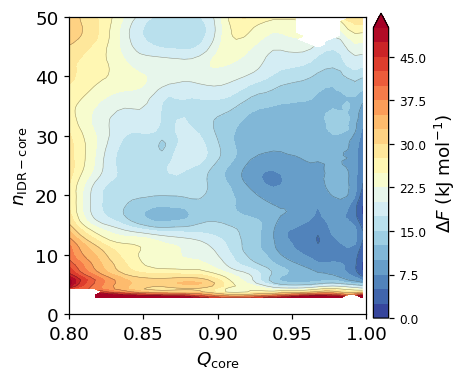

  minimum at Q_core = 0.998, n_IDR-core = 8
  largest std shown: 15.0 kJ/mol


In [2]:
# ─── Panel A: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — A
VERSION    = "v3"                # v3: apo COMPLETE at 6.0 us (1000 ns/walker)
FIGSIZE    = (4.2, 3.6)          # inches (single-column panel + colourbar;
                                 #  tall enough that the square axes box is not tiny)
XLIM       = (0.80, 1.00)        # Q_core (matched to panel C)
YLIM       = (0, 50)             # n_IDR-core
VMAX       = 50                  # kJ/mol colour ceiling
CMAP       = "RdYlBu_r"
STD_CEIL   = 15.0                # kJ/mol — truncate above this cross-snapshot std
MIN_VISITS = 5                   # colvar frames per bin below which the bin is left white
SMOOTH_SIGMA = 0.8               # display-only Gaussian smoothing of the contours, in bins
                                 # (0 = off; mask-preserving, does not move the minimum)
# NOTE: state medoids are deliberately NOT marked on this panel. They are segmented on the
# S_alpha-Q_core surface (panel C) and their n_IDR-core coordinate is single-walker-dominated
# (folded-basin structural pool is ~13/15 from replica 0) and NOT converged (MAD(n_tail_core)
# = 2.6 kJ/mol). Marking them here would plant the "folded" label in a high-F, non-converged
# tail of this surface. Medoid markers live on panel C only, where they were defined.
TITLE      = ""                  # "" for the assembled figure
OUT        = "1Nhp6A_apo_large_fes2d_qcore_nidr_fig5a"
plt.rcParams.update({"font.size": 15, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})

q, ntc, mean, std, cnt = f5.load2d("A_fes2d_qcore_nidr.dat")
F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS)
Fp = f5.smooth_masked(F, SMOOTH_SIGMA)      # smoothed only for drawing; F stays for the numbers

fig, ax = plt.subplots(figsize=FIGSIZE)
Fm = np.ma.masked_invalid(Fp)
im = ax.contourf(q, ntc, Fm.T, levels=np.linspace(0, VMAX, 21), cmap=CMAP, extend="max")
ax.contour(q, ntc, Fm.T, levels=np.arange(5, VMAX, 5), colors="k", linewidths=0.35, alpha=0.45)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
cb.ax.tick_params(labelsize=8)
ax.set_box_aspect(1)            # square AXES box; the colourbar takes its space from the
                                # figure, not from the box (set_aspect would mix CV units)
ax.set_xlabel(r"$Q_\mathrm{core}$")
ax.set_ylabel(r"$n_\mathrm{IDR-core}$")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

i, j = np.unravel_index(np.nanargmin(F), F.shape)
print(f"  minimum at Q_core = {q[i]:.3f}, n_IDR-core = {ntc[j]:.0f}")
print(f"  largest std shown: {np.nanmax(np.where(np.isfinite(F), std, np.nan)):.1f} kJ/mol")

## Panel B — per-helix helicity vs $Q_\mathrm{core}$

*"helicity is reduced mostly in helix 2, which is involved in the binding to DNA in the major mode."*

The three ALPHARMSD values have different maxima (they scale with helix length), so each is
normalised by its **folded-state** value — that is what makes "reduced *mostly* in H2" a like-for-like
comparison. Set `NORM_MODE = "none"` for raw $S_\alpha$.

folded-state <S_alpha>: helix1=8.93  helix2=8.71  helix3=20.94
  H1 (27–42)   Q=0.81:  83.0%   Q=0.99: 100.6%  (of folded)
  H2 (48–61)   Q=0.81:  46.6%   Q=0.99: 100.9%  (of folded)
  H3 (64–91)   Q=0.81:  94.5%   Q=0.99: 103.5%  (of folded)


  saved figures/1Nhp6A_apo_large_helicity_perhelix_vs_qcore_fig5b_v3.[pdf|png]  (opaque white -- not a paper panel)


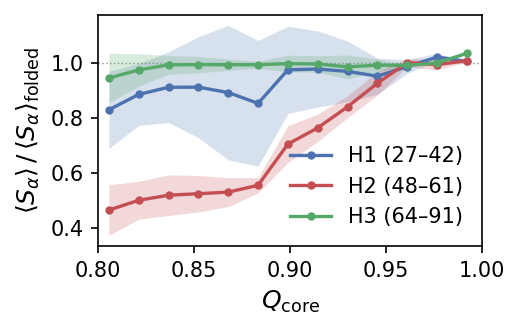

In [3]:
# ─── Panel B: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — B
VERSION     = "v3"                # v3: apo COMPLETE at 6.0 us (1000 ns/walker)
FIGSIZE     = (3.3, 2.)
XLIM        = (0.80, 1.00)      # Q_core (matched to panels A and C)
NORM_MODE   = "folded"          # "folded" (relative to the folded state) | "max" | "none"
ESS_MIN_BIN = 30                # per-bin effective sample size floor for a reweighted mean
COLOR       = {"helix1": "#4C72B0", "helix2": "#C44E52", "helix3": "#55A868"}
LABEL       = {"helix1": "H1 (27–42)", "helix2": "H2 (48–61)", "helix3": "H3 (64–91)"}
S_MAX       = {"helix1": 12.0, "helix2": 10.0, "helix3": 24.0}   # ~ n_res - 5, for NORM_MODE="max"
TITLE       = ""
OUT         = "1Nhp6A_apo_large_helicity_perhelix_vs_qcore_fig5b"
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "xtick.labelsize": 10,
                     "ytick.labelsize": 10, "legend.fontsize": 10, "axes.linewidth": 0.8,
                     "figure.dpi": 150, "axes.grid": False, "pdf.fonttype": 42})

b = f5.load1d("B_helicity_perhelix_vs_qcore.dat")
with open("analysis/figure5/B_helicity_perhelix_vs_qcore.dat") as fh:
    ref_line = [l for l in fh if "folded-state reference" in l][0]
ref = {k: float(v) for k, v in (t.split("=") for t in ref_line.split(":")[1].split())}
print("folded-state <S_alpha>:", "  ".join(f"{k}={v:.2f}" for k, v in ref.items()))

fig, ax = plt.subplots(figsize=FIGSIZE)
for h in ["helix1", "helix2", "helix3"]:
    scale = {"folded": ref[h], "max": S_MAX[h], "none": 1.0}[NORM_MODE]
    m, sd = b[f"{h}_mean"] / scale, b[f"{h}_std"] / scale
    ok = (np.isfinite(m) & (b["ess_bin"] >= ESS_MIN_BIN)
          & (b["q_core"] >= XLIM[0]) & (b["q_core"] <= XLIM[1]))
    ax.plot(b["q_core"][ok], m[ok], "-o", ms=3, lw=1.6, color=COLOR[h], label=LABEL[h])
    ax.fill_between(b["q_core"][ok], (m - sd)[ok], (m + sd)[ok], color=COLOR[h], alpha=0.22, lw=0)
    print(f"  {LABEL[h]:12s} Q={b['q_core'][ok][0]:.2f}: {100 * m[ok][0]:5.1f}%   "
          f"Q={b['q_core'][ok][-1]:.2f}: {100 * m[ok][-1]:5.1f}%  (of folded)")

ax.set_xlabel(r"$Q_\mathrm{core}$")
ax.set_ylabel({"folded": r"$\langle S_\alpha\rangle\,/\,\langle S_\alpha\rangle_\mathrm{folded}$",
               "max": "fractional helicity",
               "none": r"$\langle S_\alpha\rangle$"}[NORM_MODE])
ax.set_xlim(*XLIM)
if NORM_MODE == "folded":
    ax.axhline(1.0, color="0.6", lw=0.7, ls=":", zorder=0)
ax.legend(frameon=False, loc="lower right")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION, transparent=False)   # opaque white background (user request)
plt.show()

## Panel C — apo $F(Q_\mathrm{core},\, S_\alpha^{\mathrm{total}})$: one basin, plus a shoulder

The 2D version of the panel-B claim, on the **total** helicity of the HMG box
($S_\alpha^{\mathrm{tot}} = S_\alpha^{\mathrm{H1}} + S_\alpha^{\mathrm{H2}} + S_\alpha^{\mathrm{H3}}$),
so the axis is the overall helical content rather than one helix's.

### There is only one basin

At 5.06 µs (867 ns/walker) the surface has **a single free-energy basin**, at
$Q_\mathrm{core} \approx 1$, $S_\alpha^{\mathrm{tot}} \approx 40$. The "second state" of the earlier
version does not survive the noise floor and has been **demoted to a shoulder** — it is *not* a
metastable state, and must not be described as one.

The evidence, all on this same reweighted surface:

| | $\Delta F$ (kJ/mol) | std | counts |
|---|---|---|---|
| basin minimum | 0.00 | 0.26 | 803,705 |
| shoulder minimum | 13.61 | 0.42 | 120,433 |
| the surface *between* them | 12.58 | 3.30 | 34,885 |

The point separating them is **lower** than the shoulder itself, so nothing encloses the shoulder.
A prominence scan makes it quantitative: the raw watershed seeds 5 minima, but the count collapses
to **1 as soon as the required saddle prominence reaches 2 kJ/mol, and stays at 1 up to 10 kJ/mol**.
Every candidate second basin is separated by **less than $k_BT$ (2.49 kJ/mol)** — i.e. by less than
this surface's own $\pm 4$–$6$ kJ/mol cross-snapshot uncertainty. This is not a sampling problem:
the shoulder is *well* sampled (120k frames, std 0.42 kJ/mol). The old two-state reading was an
artefact of segmenting with no prominence threshold, which is also why its medoid kept landing off
its "well" — there was no well.

Nor was it lost to the reliability mask: at $Q_\mathrm{core} = 0.87$, $S_\alpha = 36.5$ it sits well
inside the reliable region.

### What the shoulder is

The shoulder minimum lies **13.61 kJ/mol = 5.46 $k_BT$** above the global minimum and carries
**≈ 0.5 %** of the reweighted population of the reliable region (integrated over the window below;
the Boltzmann factor at its lowest bin alone is 0.43 %).

Structurally it is **H2 melting**, and only H2 — comparing the two medoids, H1 (8.70 → 9.47) and
H3 (20.99 → 20.25) are unchanged, while **H2 collapses from 8.70 to 5.15**.

The markers are therefore *not* two basin medoids. They are:

* **1** (circle) — medoid of the one basin: `analysis/figure5/state_1_medoid.pdb`
* **2** (diamond) — representative of the **shoulder region**: `analysis/figure5/state_2_medoid.pdb`

Marker 2 is a diamond precisely so the panel does not imply a second basin. The shoulder is defined
as an explicit CV window (centre $S_\alpha = 36.5$, $Q_\mathrm{core} = 0.865$; half-widths 2.0 and
0.02) rather than as a detected basin, because a prominence threshold above the noise floor
correctly merges it away. Both are structural medoids (lowest mean heavy-atom RMSD to the rest of
their region). Regenerate with

```
python select_snapshots.py --system 1Nhp6A_apo_large_helicity \
    --f-ceil 25 --barrier 5 --delta-f 3 --t-max-ns 900 --shoulder 36.5,0.865,2.0,0.02
```

`--barrier 5` is what keeps the watershed from picking a valley-floor ripple as a "state"; `--shoulder`
then re-adds the shoulder as an explicitly labelled region, reported as `SHOULDER (not a basin)`.

### Axes and the $Q_\mathrm{core} = 1$ edge

The panel is drawn on panel A's $Q_\mathrm{core}$ window (widened slightly so neither marker is
clipped). Note this crops the surface: the reliable region actually extends down to
$Q_\mathrm{core} \approx 0.59$. Set `XLIM = (0.58, 1.01)` to see that whole melting branch.

The grid is carried out to the bins' outer **edges** (`f5.to_bin_edges`) before contouring, so the
surface reaches the physical bound $Q_\mathrm{core} = 1$ instead of stopping at the last bin centre
(0.99) — that is where the folded state, and its medoid at $Q_\mathrm{core} = 0.9995$, actually sit.
No value is invented: each border bin is extended outward by half its width.

**Why the folded medoid sits at $Q_\mathrm{core} \approx 1$ and not a little below.** `q_core` is a
Best-Hummer contact map with a *soft* switch ($\beta = 50$ nm$^{-1}$, $\lambda = 1.4$): a native
contact with reference distance 0.619 nm is only half-broken at $\lambda \times \mathrm{REF} =
0.867$ nm. In the folded medoid the largest of the 67 native C$\alpha$–C$\alpha$ distances is
0.799 nm, so every contact still scores $s \geq 0.996$ and $Q = 0.9998$. Thermal fluctuations of the
folded core simply do not move this CV — it saturates, and the folded ensemble's median is 0.9987.
$Q_\mathrm{core}$ only responds once contacts genuinely break. This is *not* the same quantity as the
`cmap` CV of the bound systems, which uses a much sharper 0.30 nm contact definition and therefore
sits at ~0.96 when folded.

Checked, not assumed: recomputing $Q$ from the medoid PDBs with the switching parameters read
straight out of `plumed_meta_2D_1Nhp6A_large.dat` reproduces the colvar values to four decimals,
which also confirms the frame-to-structure mapping in `select_snapshots.py`.

To show one helix instead, re-run `figure5_data.py --panels C --helix helix2` and point `CFILE` at
`C_pmf2d_qcore_helix2.dat` (the markers are defined on total helicity, so switch them off).


  1: Q_core = 1.0000, S_alpha_total = 39.6  [basin medoid]  -> analysis/figure5/state_1_medoid.pdb
  2: Q_core = 0.8789, S_alpha_total = 34.7  [SHOULDER (not a basin)]  -> analysis/figure5/state_2_medoid.pdb


  saved figures/1Nhp6A_apo_large_pmf2d_qcore_helicity_fig5c_v5.[pdf|png]


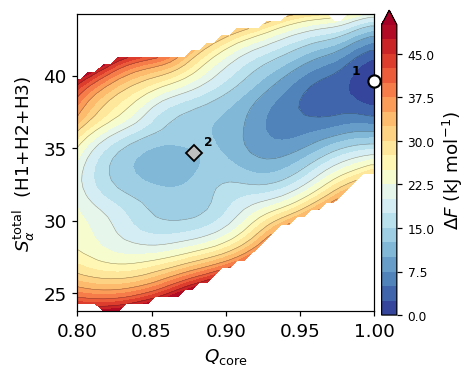

  minimum at Q_core = 0.998, S_alpha_total = 39.8


In [4]:
# ─── Panel C: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — C
VERSION    = "v5"                        # v5: basins/medoids RE-SEGMENTED on the COMPLETE 1000 ns/walker panel-C surface (v4 markers were a stale 867 ns segmentation); still one basin + a shoulder
CFILE      = "C_pmf2d_qcore_total.dat"   # total helicity = H1+H2+H3
FIGSIZE    = (4.2, 3.6)
# Panel A's Q window, widened at both ends so neither marker is clipped: the shoulder sits at
# Q=0.873, the basin medoid at Q=0.9995. The reliable region actually runs down to Q=0.59 --
# set XLIM=(0.58, 1.01) to see the whole melting branch.
XLIM       = (0.80, 1.00)     # Q_core — ends on the physical bound Q=1, where the surface ends
YLIM       = None             # None -> fit the reliable region inside XLIM; or e.g. (26, 44)
VMAX       = 50               # kJ/mol colour ceiling
CMAP       = "RdYlBu_r"
STD_CEIL   = 15.0
MIN_VISITS = 5
# The smoothing now lives in the ANALYSIS: figure5_data.py builds this surface on a fine grid
# (140x92: dq=0.005, dS_alpha=0.5) and Gaussian-smooths the reweighted DENSITY before the log
# (KDE bandwidth (0.01, 0.8) in CV units). Smoothing the density, not F, keeps barriers unbiased.
# So no display-time blur is needed here -- 0 avoids double-smoothing. (Set >0 only if you
# regenerate with --c-bw 0 0, i.e. a raw fine histogram.)
SMOOTH_SIGMA = 0.0
SHOW_MEDOIDS = True
# Marker 1 = the medoid of the ONE basin. Marker 2 = a representative of the SHOULDER, which is
# not a basin (its saddle prominence is < kBT; see the markdown above). They are drawn with
# different markers on purpose, so the panel cannot be read as showing two states.
SHOULDER_ID   = 2
BASIN_STYLE    = dict(marker="o", ms=8, mfc="white",   mec="black", mew=1.4, ls="none", zorder=5,
                      clip_on=False)   # the basin medoid sits at Q=0.9995, right on the axis spine
SHOULDER_STYLE = dict(marker="D", ms=7, mfc="0.75", mec="black", mew=1.2, ls="none", zorder=5,
                      clip_on=False)
TITLE      = ""
OUT        = "1Nhp6A_apo_large_pmf2d_qcore_helicity_fig5c"
#plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
#                     "ytick.labelsize": 9, "axes.linewidth": 0.8, "figure.dpi": 110,
#                     "axes.grid": False, "pdf.fonttype": 42})
plt.rcParams.update({"font.size": 15, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})
q, sa, mean, std, cnt = f5.load2d(CFILE)
F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS)
Fp = f5.smooth_masked(F, SMOOTH_SIGMA)   # analysis already KDE-smoothed; SMOOTH_SIGMA=0 -> no-op
# contourf paints on the bin CENTRES, so the map would stop at Q_core = 0.99 -- half a bin short of
# the Q = 1 bound, where the folded state actually lives. Carry the grid out to the bin edges.
qe, sae, Fe = f5.to_bin_edges(q, sa, Fp)

fig, ax = plt.subplots(figsize=FIGSIZE)
Fm = np.ma.masked_invalid(Fe)
im = ax.contourf(qe, sae, Fm.T, levels=np.linspace(0, VMAX, 21), cmap=CMAP, extend="max")
ax.contour(qe, sae, Fm.T, levels=np.arange(5, VMAX, 5), colors="k", linewidths=0.35, alpha=0.45)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
cb.ax.tick_params(labelsize=8)
ax.set_box_aspect(1)            # square AXES box; the colourbar takes its space from the
                                # figure, not from the box (set_aspect would mix CV units)
ax.set_xlabel(r"$Q_\mathrm{core}$")
ax.set_ylabel(r"$S_\alpha^\mathrm{total}$  (H1+H2+H3)")
ax.set_xlim(*XLIM)
if YLIM:
    ax.set_ylim(*YLIM)
else:                     # fit the reliable region *within* XLIM
    rows = np.isfinite(Fe[(qe >= XLIM[0]) & (qe <= XLIM[1])]).any(0)
    ax.set_ylim(sae[rows].min(), sae[rows].max())

# the structures shown as snapshots, at their true (Q_core, S_alpha) coordinates
if SHOW_MEDOIDS:
    state, hel, qc, names = f5.load_medoids("C_medoids_cvs.dat")   # cv1=total_helicity, cv2=q_core
    for s, h, x in zip(state, hel, qc):
        is_sh = int(s) == SHOULDER_ID
        ax.plot([x], [h], **(SHOULDER_STYLE if is_sh else BASIN_STYLE))
        # label goes to the left of a marker near the right edge, otherwise it runs into the
        # colourbar; to the right of any other
        off = (-15, 5) if x > XLIM[1] - 0.04 else (6, 5)
        ax.annotate(str(s), (x, h), textcoords="offset points", xytext=off,
                    fontsize=8, fontweight="bold", color="black", zorder=6)
        kind = "SHOULDER (not a basin)" if is_sh else "basin medoid"
        print(f"  {s}: Q_core = {x:.4f}, S_alpha_total = {h:.1f}  [{kind}]"
              f"  -> analysis/figure5/state_{s}_medoid.pdb")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

i, j = np.unravel_index(np.nanargmin(F), F.shape)
print(f"  minimum at Q_core = {q[i]:.3f}, S_alpha_total = {sa[j]:.1f}")

## Panel D1 — DNA bend angle, free DNA vs bound

*"the DNA duplex indeed bends in the presence of Nhp6A relative to reference simulations for the DNA
alone … spanning from ~10º for free DNA to ~30º in presence of Nhp6A."*

Curves are truncated to the region whose cross-snapshot std stays ≤ `STD_CEIL`, contiguous from the
minimum — beyond it the spectator is too thinly sampled to mean anything.

  DNA alone   minimum at   8.2 deg   (reliable 0.8 – 89.2)
  Nhp6A:DNA   minimum at  30.8 deg   (reliable 0.8 – 78.8)


  saved figures/1Nhp6A_wall_pmf_bend_vs_dna_fig5d1_v2.[pdf|png]


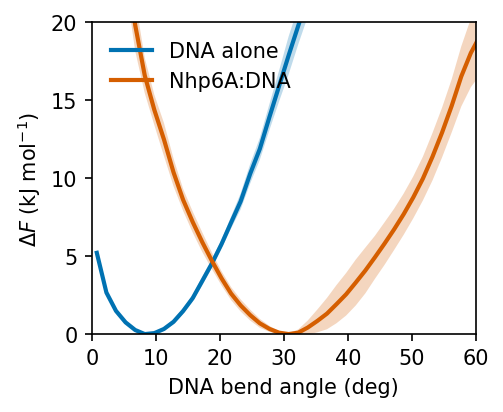

In [5]:
# ─── Panel D1: everything this figure needs ───────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — D1
VERSION  = "v2"          # v2: free-DNA reference rebuilt on DNA_wall2 (corrected dna_end2)
FIGSIZE  = (3.3, 2.7)
XLIM     = (0, 60)          # degrees
YLIM     = (0, 20)          # kJ/mol
STD_CEIL = 15.0             # kJ/mol — reliability truncation
SYS      = {"DNA":  dict(label="DNA alone", color="#0072B2"),      # Okabe-Ito
            "holo": dict(label="Nhp6A:DNA", color="#D55E00")}
TITLE    = ""
OUT      = "1Nhp6A_wall_pmf_bend_vs_dna_fig5d1"
plt.rcParams.update({"font.size": 12, "axes.labelsize": 10, "xtick.labelsize": 10,
                     "ytick.labelsize": 10, "legend.fontsize": 10, "axes.linewidth": 0.8,
                     "figure.dpi": 150, "axes.grid": False, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=FIGSIZE)
for name, s in SYS.items():
    d = f5.load1d(f"D_pmf_bend_{name}.dat")
    x, m, sd = d[list(d)[0]], d["F_mean"], d["F_std"]
    ok = f5.reliable_1d(m, sd, STD_CEIL)
    ax.plot(x[ok], m[ok], lw=2, color=s["color"], label=s["label"])
    ax.fill_between(x[ok], (m - sd)[ok], (m + sd)[ok], color=s["color"], alpha=0.25, lw=0)
    print(f"  {s['label']:11s} minimum at {x[ok][np.nanargmin(m[ok])]:5.1f} deg"
          f"   (reliable {x[ok].min():.1f} – {x[ok].max():.1f})")

ax.set_xlabel("DNA bend angle (deg)")
ax.set_ylabel(r"$\Delta F$ (kJ mol$^{-1}$)")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.legend(frameon=False, loc="upper left")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

## Panel D2 — end-to-end distance, free DNA vs bound

$d_\mathrm{e-e}$ is the *biased* CV in both runs, so this is the best-determined comparison of the
two; the bend angle above is a spectator reweighted onto it.

  DNA alone   minimum at  4.63 nm   (reliable 2.42 – 5.98)
  Nhp6A:DNA   minimum at  4.04 nm   (reliable 2.60 – 5.98)
  saved figures/1Nhp6A_wall_pmf_de2e_vs_dna_fig5d2_v2.[pdf|png]


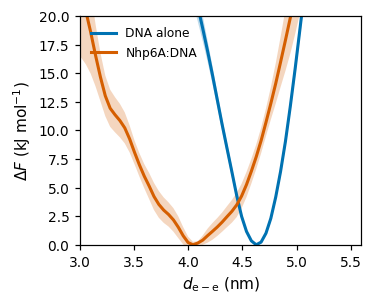

In [6]:
# ─── Panel D2: everything this figure needs ───────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — D2
VERSION  = "v2"          # v2: free-DNA reference rebuilt on DNA_wall2 (corrected dna_end2)
FIGSIZE  = (3.3, 2.7)
XLIM     = (3.0, 5.6)       # nm
YLIM     = (0, 20)          # kJ/mol
STD_CEIL = 15.0
SYS      = {"DNA":  dict(label="DNA alone", color="#0072B2"),
            "holo": dict(label="Nhp6A:DNA", color="#D55E00")}
TITLE    = ""
OUT      = "1Nhp6A_wall_pmf_de2e_vs_dna_fig5d2"
plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 8, "axes.linewidth": 0.8,
                     "figure.dpi": 110, "axes.grid": False, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=FIGSIZE)
for name, s in SYS.items():
    d = f5.load1d(f"D_pmf_de2e_{name}.dat")
    x, m, sd = d[list(d)[0]], d["F_mean"], d["F_std"]
    ok = f5.reliable_1d(m, sd, STD_CEIL)
    ax.plot(x[ok], m[ok], lw=2, color=s["color"], label=s["label"])
    ax.fill_between(x[ok], (m - sd)[ok], (m + sd)[ok], color=s["color"], alpha=0.25, lw=0)
    print(f"  {s['label']:11s} minimum at {x[ok][np.nanargmin(m[ok])]:5.2f} nm"
          f"   (reliable {x[ok].min():.2f} – {x[ok].max():.2f})")

ax.set_xlabel(r"$d_\mathrm{e-e}$ (nm)")
ax.set_ylabel(r"$\Delta F$ (kJ mol$^{-1}$)")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.legend(frameon=False, loc="upper left")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

## Panel E — $F(\mathrm{bend},\, n_\mathrm{IDR-DNA})$

*"bending is possible only upon formation of IDR–DNA contacts, suggesting a decisive role for the
protein IDR."*

DNA bend angle on the x-axis, $n_\mathrm{IDR-DNA}$ on the y-axis — so the bending coordinate reads
left-to-right, consistent with panels D1/D2.

  saved figures/1Nhp6A_wall_pmf2d_idrdna_bend_fig5e_v2.[pdf|png]


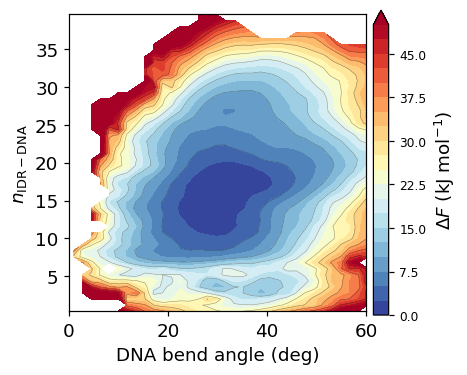

  few IDR–DNA contacts (<10)  : minimum at 30 deg, resolved out to 80 deg
  many IDR–DNA contacts (>=20): minimum at 32 deg, resolved out to 89 deg


In [7]:
# ─── Panel E: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — E
VERSION    = "v2"            # v2: transposed -> bend angle on x, n_IDR-DNA on y
FIGSIZE    = (4.2, 3.6)
XLIM       = (0, 60)         # DNA bend angle (deg) — matched to panels D1/D2
YLIM       = None            # n_IDR-DNA
VMAX       = 50              # kJ/mol colour ceiling
CMAP       = "RdYlBu_r"
STD_CEIL   = 15.0
MIN_VISITS = 5
TITLE      = ""
OUT        = "1Nhp6A_wall_pmf2d_idrdna_bend_fig5e"

plt.rcParams.update({"font.size": 15, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})

nc, bend, mean, std, cnt = f5.load2d("E_pmf2d_idrdna_bend.dat")
F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS)   # F indexed [nc, bend]

fig, ax = plt.subplots(figsize=FIGSIZE)
Fm = np.ma.masked_invalid(F)
# transposed axes: bend on x, n_IDR-DNA on y. contourf(X, Y, Z) wants Z shape (len(Y), len(X)),
# i.e. (len(nc), len(bend)) = F itself (not F.T).
im = ax.contourf(bend, nc, Fm, levels=np.linspace(0, VMAX, 21), cmap=CMAP, extend="max")
ax.contour(bend, nc, Fm, levels=np.arange(5, VMAX, 5), colors="k", linewidths=0.35, alpha=0.45)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
cb.ax.tick_params(labelsize=8)
ax.set_box_aspect(1)            # square AXES box; the colourbar takes its space from the
                                # figure, not from the box (set_aspect would mix CV units)
ax.set_xlabel("DNA bend angle (deg)")
ax.set_ylabel(r"$n_\mathrm{IDR-DNA}$")
if XLIM:
    ax.set_xlim(*XLIM)
if YLIM:
    ax.set_ylim(*YLIM)
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

# quantify the claim: how far can the DNA bend at low vs high IDR-DNA contact number?
for lab, sl in [("few IDR–DNA contacts (<10)", nc < 10), ("many IDR–DNA contacts (>=20)", nc >= 20)]:
    col = np.nanmin(np.where(np.isfinite(F[sl]), F[sl], np.nan), axis=0)
    if np.isfinite(col).any():
        print(f"  {lab:28s}: minimum at {bend[np.nanargmin(col)]:.0f} deg, "
              f"resolved out to {bend[np.isfinite(col)].max():.0f} deg")

## Panel F1 — the 2:1 complex: H3 distortion

*"Already in the short equilibrium simulations we find that the complex experiences large
distortions, particularly in helix H3."*

**Unbiased equilibrium MD only.** The 2Nhp6A metadynamics run fails its reweighting gate
(ESS ≈ 0 %, MAD = 4.7 kJ/mol), so no free energy may be quoted from it. H3 is Pro64–Ala93 (1LWM).
A single observable is shown — the **H3 backbone RMSD** from the reference — which captures the
distortion directly (the earlier helicity and kink-angle traces are dropped: helicity alone is blind
to the hinge motion, and RMSD already reports it).

  copy A  H3 RMSD (nm)         0.241 +/- 0.072
  copy B  H3 RMSD (nm)         0.484 +/- 0.208
  saved figures/2Nhp6A_equil_h3_distortion_fig5f1_v2.[pdf|png]


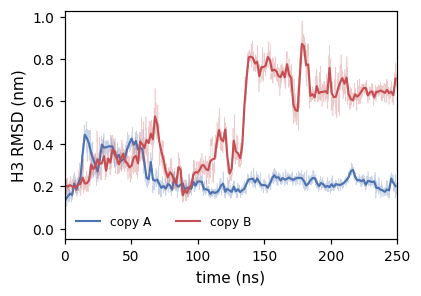

In [8]:
# ─── Panel F1: everything this figure needs ───────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — F1
VERSION    = "v2"          # v2: RMSD only (one panel), dropped helicity/kink subplots
OBS        = ["H3_RMSD_nm"]                                # RMSD is the H3-distortion observable kept
LABEL      = {"H3_helicity": "H3 helicity", "H3_RMSD_nm": "H3 RMSD (nm)",
              "H3_kink_deg": "H3 kink (deg)", "H3_displacement_nm": "H3 displacement (nm)",
              "HMG_helicity": "HMG helicity"}
COLOR      = {"A": "#4C72B0", "B": "#C44E52"}               # the two protein copies
FIGSIZE    = (3.9, 2.7)
N_BLOCKS   = 150            # block average drawn over the raw trace, for readability
TITLE      = ""
OUT        = "2Nhp6A_equil_h3_distortion_fig5f1"
plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 8, "axes.linewidth": 0.8,
                     "figure.dpi": 110, "axes.grid": False, "pdf.fonttype": 42})

f1 = f5.load1d("F1_equil_2Nhp6A_h3.dat")
t = f1["time_ns"]
copies = sorted({k.rsplit("_", 1)[1] for k in f1 if k != "time_ns"})

fig, axes = plt.subplots(len(OBS), 1, figsize=FIGSIZE, sharex=True)
for ax, key in zip(np.atleast_1d(axes), OBS):
    for cp in copies:
        y = f1[f"{key}_{cp}"]
        ax.plot(t, y, lw=0.4, alpha=0.30, color=COLOR[cp])
        k = max(1, len(y) // N_BLOCKS)
        ax.plot(t[:len(y) // k * k].reshape(-1, k).mean(1),
                y[:len(y) // k * k].reshape(-1, k).mean(1),
                lw=1.4, color=COLOR[cp], label=f"copy {cp}")
        print(f"  copy {cp}  {LABEL[key]:18s} {y.mean():7.3f} +/- {y.std():.3f}")
    ax.set_ylabel(LABEL[key])
    ax.set_xlim(0, t[-1])          # time series: 0 -> final time, always
np.atleast_1d(axes)[0].legend(frameon=False, ncol=len(copies), loc="lower left")
np.atleast_1d(axes)[-1].set_xlabel("time (ns)")
if TITLE:
    np.atleast_1d(axes)[0].set_title(TITLE)
fig.align_ylabels(np.atleast_1d(axes))
f5.savepanel(fig, OUT, VERSION)
plt.show()

  saved figures/2Nhp6A_equil_h3_distortion_rep2_fig5f1_v1.[pdf|png]
  copy A  H3_RMSD_nm     0.183 +/- 0.026
  copy B  H3_RMSD_nm     0.327 +/- 0.094


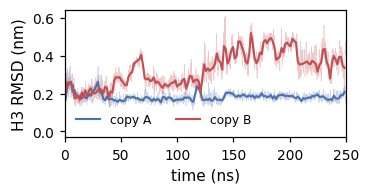

In [9]:
# ─── Panel F1 — replicate 2 (PBC-clean) ───────────────────────────────────────
# The default F1 above is rep0, which is PBC-flagged (copy-B H3 swing coincides with a marginal
# min-image contact). rep2 has no such artifact. Rendered through the same f5.f1_panel() helper
# so it is directly comparable to F1 above (identical observable, axes, colours, block averaging).
# Use it to decide which replicate the paper shows. rep2 still shows the H3 distortion of copy B
# (mean 0.33 vs copy A 0.18 nm), milder than rep0's 0.48; rep1 (0.23) is milder still -- the
# distortion magnitude is replicate-dependent.
import sys
sys.path.insert(0, "analysis/scripts")
import matplotlib.pyplot as plt
import figure5_plot as f5
FIGSIZE  = (3.3, 1.5)
VERSION = "v1"          # v1: first render of the rep2 variant
OUT     = "2Nhp6A_equil_h3_distortion_rep2_fig5f1"
plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 8, "axes.linewidth": 0.8,
                     "figure.dpi": 110, "axes.grid": False, "pdf.fonttype": 42})

stats = f5.f1_panel("F1_equil_2Nhp6A_h3_rep2.dat", out=OUT, version=VERSION,
                    obs=("H3_RMSD_nm",), title="", figsize=FIGSIZE)
for (obs, cp), (mean, sd) in stats.items():
    print(f"  copy {cp}  {obs:12s} {mean:7.3f} +/- {sd:.3f}")
plt.show()

## Panel F2 — bending in the 2:1 complex

*"Due to the large steric hindrance between the two Nhp6As, the degree of bending does not reach
that of the 1:1 complex."*

The honest comparison is **unbiased vs unbiased**: equilibrium bend-angle distributions. The
equilibrium campaign is still running round-robin, so this renders whatever replicas exist and says
which are missing. (Comparing the trimer's *biased* distribution against a *reweighted* 1:1 PMF
would not be a valid comparison, and is deliberately not done.)

  2Nhp6A:DNA   mean bend = 14.6 deg  (3,750,003.0 frames)
  Nhp6A:DNA    mean bend = 32.3 deg  (3,750,003.0 frames)
  DNA alone    mean bend = 10.2 deg  (1,875,003.0 frames)
  saved figures/2Nhp6A_equil_bend_compare_fig5f2_v2.[pdf|png]


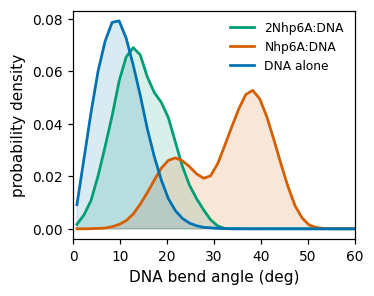

In [10]:
# ─── Panel F2: everything this figure needs ───────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — F2
VERSION = "v2"          # v2: all 3 systems x 3 reps (v1 had a path bug: 2Nhp6A rep0 only)
FIGSIZE = (3.3, 2.7)
XLIM    = (0, 60)        # degrees
REBIN   = 3              # the .dat histogram has 180 bins; coarsen for display
SYS     = {"2Nhp6A":      ("2Nhp6A:DNA", "#009E73"),
           "1Nhp6A_wall": ("Nhp6A:DNA",  "#D55E00"),
           "DNA_wall":    ("DNA alone",  "#0072B2")}
TITLE   = ""
OUT     = "2Nhp6A_equil_bend_compare_fig5f2"
plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 8, "axes.linewidth": 0.8,
                     "figure.dpi": 110, "axes.grid": False, "pdf.fonttype": 42})

f2 = f5.load1d("F2_equil_bend_hist.dat")
x = f2["bend_deg"]
present = [s for s in SYS if f"counts_{s}" in f2]
missing = [s for s in SYS if s not in present]

fig, ax = plt.subplots(figsize=FIGSIZE)
for s in present:
    lab, col = SYS[s]
    c = f2[f"counts_{s}"]
    n = len(c) // REBIN * REBIN
    cc = c[:n].reshape(-1, REBIN).sum(1)
    xx = x[:n].reshape(-1, REBIN).mean(1)
    dens = cc / (cc.sum() * (xx[1] - xx[0]))
    ax.plot(xx, dens, lw=1.8, color=col, label=lab)
    ax.fill_between(xx, 0, dens, color=col, alpha=0.15)
    print(f"  {lab:12s} mean bend = {np.sum(xx * cc) / cc.sum():.1f} deg  ({cc.sum():,} frames)")

ax.set_xlabel("DNA bend angle (deg)")
ax.set_ylabel("probability density")
ax.set_xlim(*XLIM)
ax.legend(frameon=False)
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

if missing:
    print("\nPARTIAL — still missing equilibrium data for: " + ", ".join(missing))
    print("Re-run figure5_data.py --panels F when the campaign delivers them.")

## Provenance stamp

Writes `figures/figure5_provenance.txt` — which dataset produced each panel, how long it ran, which
gates it passed, what is still preliminary. Keep it with the figure: it is what makes the panels
traceable when the paper comes back from review.

In [11]:
# ─── Provenance stamp: everything this cell needs ─────────────────────────────
import datetime
import socket
import sys
sys.path.insert(0, "analysis/scripts")
import figure5_plot as f5

VERSION = "v1"          # keep in step with the panels above
STD_CEIL, MIN_VISITS, ESS_MIN_BIN = 10.0, 5, 30    # the filters the panels applied

META = f5.load_meta()
lines = [f"Figure 5 — provenance ({VERSION})",
         f"panels rendered {datetime.datetime.now():%Y-%m-%d %H:%M} on {socket.gethostname()} "
         f"by analysis_figure5.ipynb",
         f"data computed {META['generated']} on {META['host']} by analysis/scripts/figure5_data.py "
         f"(stride {META['stride']}, {META['n_snaps']} snapshots)",
         f"plot-time filters: std ceiling {STD_CEIL} kJ/mol, min visits {MIN_VISITS}, "
         f"ESS floor {ESS_MIN_BIN}",
         ""]
for k in ("A", "B", "C", "D", "E", "F1", "F2", "reweighting_apo"):
    if k in META:
        lines.append(f"[{k}]")
        for kk, vv in META[k].items():
            lines.append(f"    {kk:20s} {vv}")
        lines.append("")
lines += ["FLAGS"] + [f"  - {f}" for f in META["flags"]]

with open("figures/figure5_provenance.txt", "w") as fh:
    fh.write("\n".join(lines) + "\n")
print("\n".join(lines))
print("\nwrote figures/figure5_provenance.txt")

Figure 5 — provenance (v1)
panels rendered 2026-08-02 14:12 by analysis_figure5.ipynb
data computed 2026-07-31 13:10 by analysis/scripts/figure5_data.py (stride 1, 5 snapshots)
plot-time filters: std ceiling 10.0 kJ/mol, min visits 5, ESS floor 30

[A]
    data                 data/1Nhp6A_apo_large
    walkers              6
    ns_per_walker        1000.0
    method               c(t)-reweighted 2D PMF (both CVs biased)
    n_snaps              5
    minimum              {'q_core': 0.998, 'n_idr_core': 8.2}
    preliminary          False

[B]
    data                 data/1Nhp6A_apo_large
    method               c(t)-reweighted profile
    folded_reference     {'helix1': 8.931967870696042, 'helix2': 8.713650942562882, 'helix3': 20.937720266135727}
    folded_q             0.95
    n_snaps              5
    preliminary          False

[C]
    data                 data/1Nhp6A_apo_large
    method               c(t)-reweighted 2D PMF
    helix                total
    bins             

## Alternative panels: genuine Best-Hummer $Q$

Same panels A/B/C, with the **biased** CV `q_core` replaced by an **unbiased spectator** Best-Hummer $Q$ over the core (heavy atoms, 0.45 nm native cutoff, $\lambda=1.8$; Best, Hummer & Eaton PNAS 2013), computed with `plumed driver` over the RAW 2 ps trajectories (3,000,006 frames) and c(t)-reweighted by `analysis/scripts/reweight_qbh.py`.

**Why.** `q_core` is a C$\alpha$-only map at a 0.65 nm cutoff: measured on the reference structure it is a strict *subset* of the project's all-atom map (67 residue pairs vs 103, 14 tertiary vs 43), nearly blind to the H1-H2 interface (2 contacts vs 17) and completely blind to H2-H3 (0 vs 2), with 75% of its weight on $i,i{+}4$ intra-helical pairs. It therefore falls steeply on helix fraying but barely responds to loss of tertiary packing, and below $q_\mathrm{core}\approx0.6$ it decouples from RMSD (RMSD moves <0.4 A while $q_\mathrm{core}$ drops four-fold).

**The two coordinates do NOT share a scale** (pearson $r=0.976$, but with a systematic offset of $-0.041$ to $-0.047$ at high $Q$): the panel-C shoulder at $q_\mathrm{core}=0.879$ maps to $Q=0.835\pm0.022$, and the folded basin at $q_\mathrm{core}=0.998$ to $Q=0.948\pm0.015$. Hence `XLIM = (0.78, 1.00)` here, not (0.80, 1.00).

Reweighting gate PASSES on the same criterion as the originals: MAD(bulk $q<0.93$) = 2.48, MAD($n_\mathrm{IDR}$) = 1.90 kJ/mol vs threshold 2.99; ESS = 101,924 (3.41%).

All specs (CMAP, VMAX, STD_CEIL, rcParams, figure size) are **identical** to the q_core cells above -- only the input file, output name and axis label differ.

  saved figures/1Nhp6A_apo_large_fes2d_qbh_nidr_fig5a_v1.[pdf|png]


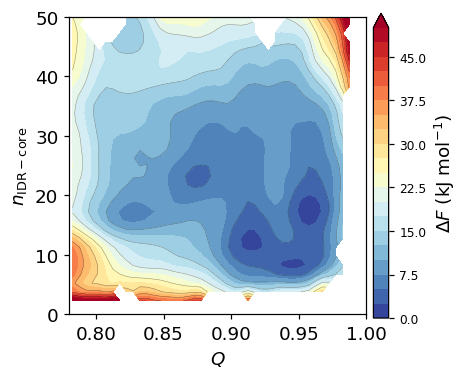

  minimum at Q = 0.958, n_IDR-core = 17
  largest std shown: 15.0 kJ/mol


In [12]:
# ─── Panel A: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — A
VERSION    = "v1"                # v3: apo COMPLETE at 6.0 us (1000 ns/walker)
FIGSIZE    = (4.2, 3.6)          # inches (single-column panel + colourbar;
                                 #  tall enough that the square axes box is not tiny)
XLIM       = (0.78, 1.00)        # Q (genuine Best-Hummer; NOT the q_core scale)
YLIM       = (0, 50)             # n_IDR-core
VMAX       = 50                  # kJ/mol colour ceiling
CMAP       = "RdYlBu_r"
STD_CEIL   = 15.0                # kJ/mol — truncate above this cross-snapshot std
MIN_VISITS = 5                   # colvar frames per bin below which the bin is left white
SMOOTH_SIGMA = 0.8               # display-only Gaussian smoothing of the contours, in bins
                                 # (0 = off; mask-preserving, does not move the minimum)
# NOTE: state medoids are deliberately NOT marked on this panel. They are segmented on the
# S_alpha-Q_core surface (panel C) and their n_IDR-core coordinate is single-walker-dominated
# (folded-basin structural pool is ~13/15 from replica 0) and NOT converged (MAD(n_tail_core)
# = 2.6 kJ/mol). Marking them here would plant the "folded" label in a high-F, non-converged
# tail of this surface. Medoid markers live on panel C only, where they were defined.
TITLE      = ""                  # "" for the assembled figure
OUT        = "1Nhp6A_apo_large_fes2d_qbh_nidr_fig5a"
plt.rcParams.update({"font.size": 15, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})

q, ntc, mean, std, cnt = f5.load2d("A_fes2d_qbh_nidr.dat")
F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS)
Fp = f5.smooth_masked(F, SMOOTH_SIGMA)      # smoothed only for drawing; F stays for the numbers

fig, ax = plt.subplots(figsize=FIGSIZE)
Fm = np.ma.masked_invalid(Fp)
im = ax.contourf(q, ntc, Fm.T, levels=np.linspace(0, VMAX, 21), cmap=CMAP, extend="max")
ax.contour(q, ntc, Fm.T, levels=np.arange(5, VMAX, 5), colors="k", linewidths=0.35, alpha=0.45)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
cb.ax.tick_params(labelsize=8)
ax.set_box_aspect(1)            # square AXES box; the colourbar takes its space from the
                                # figure, not from the box (set_aspect would mix CV units)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$n_\mathrm{IDR-core}$")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

i, j = np.unravel_index(np.nanargmin(F), F.shape)
print(f"  minimum at Q = {q[i]:.3f}, n_IDR-core = {ntc[j]:.0f}")
print(f"  largest std shown: {np.nanmax(np.where(np.isfinite(F), std, np.nan)):.1f} kJ/mol")

folded-state <S_alpha>: helix1=8.91  helix2=8.78  helix3=21.05
  H1 (27–42)   Q=0.78:  79.1%   Q=0.98: 100.4%  (of folded)
  H2 (48–61)   Q=0.78:  42.8%   Q=0.98: 101.5%  (of folded)
  H3 (64–91)   Q=0.78:  91.4%   Q=0.98: 102.6%  (of folded)
  saved figures/1Nhp6A_apo_large_helicity_perhelix_vs_qbh_fig5b_v1.[pdf|png]  (opaque white -- not a paper panel)


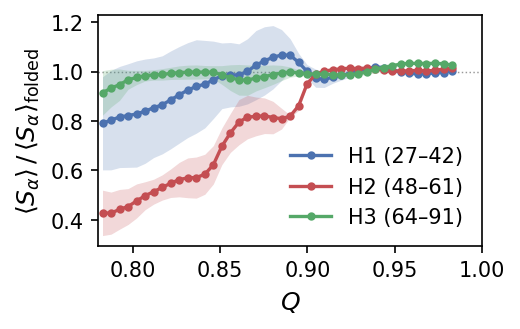

In [13]:
# ─── Panel B: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — B
VERSION     = "v1"                # v3: apo COMPLETE at 6.0 us (1000 ns/walker)
FIGSIZE     = (3.3, 2.)
XLIM        = (0.78, 1.00)      # Q (genuine Best-Hummer scale)
NORM_MODE   = "folded"          # "folded" (relative to the folded state) | "max" | "none"
ESS_MIN_BIN = 30                # per-bin effective sample size floor for a reweighted mean
COLOR       = {"helix1": "#4C72B0", "helix2": "#C44E52", "helix3": "#55A868"}
LABEL       = {"helix1": "H1 (27–42)", "helix2": "H2 (48–61)", "helix3": "H3 (64–91)"}
S_MAX       = {"helix1": 12.0, "helix2": 10.0, "helix3": 24.0}   # ~ n_res - 5, for NORM_MODE="max"
TITLE       = ""
OUT         = "1Nhp6A_apo_large_helicity_perhelix_vs_qbh_fig5b"
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "xtick.labelsize": 10,
                     "ytick.labelsize": 10, "legend.fontsize": 10, "axes.linewidth": 0.8,
                     "figure.dpi": 150, "axes.grid": False, "pdf.fonttype": 42})

b = f5.load1d("B_helicity_perhelix_vs_qbh.dat")
with open("analysis/figure5/B_helicity_perhelix_vs_qbh.dat") as fh:
    ref_line = [l for l in fh if "folded-state reference" in l][0]
ref = {k: float(v) for k, v in (t.split("=") for t in ref_line.split(":")[1].split())}
print("folded-state <S_alpha>:", "  ".join(f"{k}={v:.2f}" for k, v in ref.items()))

fig, ax = plt.subplots(figsize=FIGSIZE)
for h in ["helix1", "helix2", "helix3"]:
    scale = {"folded": ref[h], "max": S_MAX[h], "none": 1.0}[NORM_MODE]
    m, sd = b[f"{h}_mean"] / scale, b[f"{h}_std"] / scale
    ok = (np.isfinite(m) & (b["ess_bin"] >= ESS_MIN_BIN)
          & (b["Q"] >= XLIM[0]) & (b["Q"] <= XLIM[1]))
    ax.plot(b["Q"][ok], m[ok], "-o", ms=3, lw=1.6, color=COLOR[h], label=LABEL[h])
    ax.fill_between(b["Q"][ok], (m - sd)[ok], (m + sd)[ok], color=COLOR[h], alpha=0.22, lw=0)
    print(f"  {LABEL[h]:12s} Q={b["Q"][ok][0]:.2f}: {100 * m[ok][0]:5.1f}%   "
          f"Q={b["Q"][ok][-1]:.2f}: {100 * m[ok][-1]:5.1f}%  (of folded)")

ax.set_xlabel(r"$Q$")
ax.set_ylabel({"folded": r"$\langle S_\alpha\rangle\,/\,\langle S_\alpha\rangle_\mathrm{folded}$",
               "max": "fractional helicity",
               "none": r"$\langle S_\alpha\rangle$"}[NORM_MODE])
ax.set_xlim(*XLIM)
if NORM_MODE == "folded":
    ax.axhline(1.0, color="0.6", lw=0.7, ls=":", zorder=0)
ax.legend(frameon=False, loc="lower right")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION, transparent=False)   # opaque white background (user request)
plt.show()

  saved figures/1Nhp6A_apo_large_pmf2d_qbh_helicity_fig5c_v1.[pdf|png]


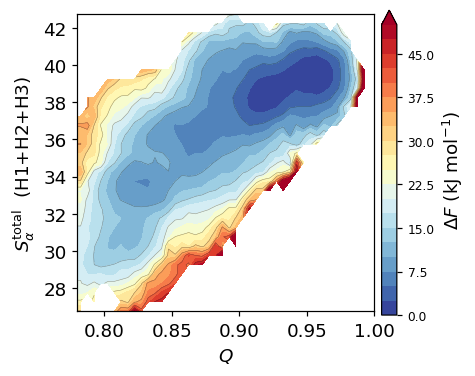

  minimum at Q = 0.958, S_alpha_total = 39.8


In [14]:
# ─── Panel C: everything this figure needs ────────────────────────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — C
VERSION    = "v1"                        # v5: basins/medoids RE-SEGMENTED on the COMPLETE 1000 ns/walker panel-C surface (v4 markers were a stale 867 ns segmentation); still one basin + a shoulder
CFILE      = "C_pmf2d_qbh_total.dat"   # total helicity = H1+H2+H3
FIGSIZE    = (4.2, 3.6)
# Panel A's Q window, widened at both ends so neither marker is clipped: the shoulder sits at
# Q=0.873, the basin medoid at Q=0.9995. The reliable region actually runs down to Q=0.59 --
# set XLIM=(0.58, 1.01) to see the whole melting branch.
XLIM       = (0.78, 1.00)     # Q — ends on the physical bound Q=1, where the surface ends
YLIM       = None             # None -> fit the reliable region inside XLIM; or e.g. (26, 44)
VMAX       = 50               # kJ/mol colour ceiling
CMAP       = "RdYlBu_r"
STD_CEIL   = 15.0
MIN_VISITS = 5
# The smoothing now lives in the ANALYSIS: figure5_data.py builds this surface on a fine grid
# (140x92: dq=0.005, dS_alpha=0.5) and Gaussian-smooths the reweighted DENSITY before the log
# (KDE bandwidth (0.01, 0.8) in CV units). Smoothing the density, not F, keeps barriers unbiased.
# So no display-time blur is needed here -- 0 avoids double-smoothing. (Set >0 only if you
# regenerate with --c-bw 0 0, i.e. a raw fine histogram.)
SMOOTH_SIGMA = 0.0
# The medoids in C_medoids_cvs.dat were segmented on the q_core surface; their
# coordinates do NOT transfer to the Q axis. Re-segment with select_snapshots.py
# against C_pmf2d_qbh_total.dat before marking anything here.
SHOW_MEDOIDS = False
# Marker 1 = the medoid of the ONE basin. Marker 2 = a representative of the SHOULDER, which is
# not a basin (its saddle prominence is < kBT; see the markdown above). They are drawn with
# different markers on purpose, so the panel cannot be read as showing two states.
SHOULDER_ID   = 2
BASIN_STYLE    = dict(marker="o", ms=8, mfc="white",   mec="black", mew=1.4, ls="none", zorder=5,
                      clip_on=False)   # the basin medoid sits at Q=0.9995, right on the axis spine
SHOULDER_STYLE = dict(marker="D", ms=7, mfc="0.75", mec="black", mew=1.2, ls="none", zorder=5,
                      clip_on=False)
TITLE      = ""
OUT        = "1Nhp6A_apo_large_pmf2d_qbh_helicity_fig5c"
#plt.rcParams.update({"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9,
#                     "ytick.labelsize": 9, "axes.linewidth": 0.8, "figure.dpi": 110,
#                     "axes.grid": False, "pdf.fonttype": 42})
plt.rcParams.update({"font.size": 15, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})
q, sa, mean, std, cnt = f5.load2d(CFILE)
F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS)
Fp = f5.smooth_masked(F, SMOOTH_SIGMA)   # analysis already KDE-smoothed; SMOOTH_SIGMA=0 -> no-op
# contourf paints on the bin CENTRES, so the map would stop at Q_core = 0.99 -- half a bin short of
# the Q = 1 bound, where the folded state actually lives. Carry the grid out to the bin edges.
qe, sae, Fe = f5.to_bin_edges(q, sa, Fp)

fig, ax = plt.subplots(figsize=FIGSIZE)
Fm = np.ma.masked_invalid(Fe)
im = ax.contourf(qe, sae, Fm.T, levels=np.linspace(0, VMAX, 21), cmap=CMAP, extend="max")
ax.contour(qe, sae, Fm.T, levels=np.arange(5, VMAX, 5), colors="k", linewidths=0.35, alpha=0.45)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
cb.ax.tick_params(labelsize=8)
ax.set_box_aspect(1)            # square AXES box; the colourbar takes its space from the
                                # figure, not from the box (set_aspect would mix CV units)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$S_\alpha^\mathrm{total}$  (H1+H2+H3)")
ax.set_xlim(*XLIM)
if YLIM:
    ax.set_ylim(*YLIM)
else:                     # fit the reliable region *within* XLIM
    rows = np.isfinite(Fe[(qe >= XLIM[0]) & (qe <= XLIM[1])]).any(0)
    ax.set_ylim(sae[rows].min(), sae[rows].max())

# the structures shown as snapshots, at their true (Q_core, S_alpha) coordinates
if SHOW_MEDOIDS:
    state, hel, qc, names = f5.load_medoids("C_medoids_cvs.dat")   # cv1=total_helicity, cv2=q_core
    for s, h, x in zip(state, hel, qc):
        is_sh = int(s) == SHOULDER_ID
        ax.plot([x], [h], **(SHOULDER_STYLE if is_sh else BASIN_STYLE))
        # label goes to the left of a marker near the right edge, otherwise it runs into the
        # colourbar; to the right of any other
        off = (-15, 5) if x > XLIM[1] - 0.04 else (6, 5)
        ax.annotate(str(s), (x, h), textcoords="offset points", xytext=off,
                    fontsize=8, fontweight="bold", color="black", zorder=6)
        kind = "SHOULDER (not a basin)" if is_sh else "basin medoid"
        print(f"  {s}: Q_core = {x:.4f}, S_alpha_total = {h:.1f}  [{kind}]"
              f"  -> analysis/figure5/state_{s}_medoid.pdb")
if TITLE:
    ax.set_title(TITLE)
f5.savepanel(fig, OUT, VERSION)
plt.show()

i, j = np.unravel_index(np.nanargmin(F), F.shape)
print(f"  minimum at Q = {q[i]:.3f}, S_alpha_total = {sa[j]:.1f}")